# Solar Energy Forecasting

This notebook analyzes solar generation and weather data from two photovoltaic plants and builds a short-term Random Forest forecasting model.

The workflow follows the case-study report: data cleaning, plant-level aggregation, weather matching, exploratory analysis, lag-feature engineering, chronological 80:20 validation, and Random Forest evaluation.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## 2. Load the four datasets

In [2]:
DATA_DIR = Path("../dataset")
if not DATA_DIR.exists():
    DATA_DIR = Path(".")

files = [
    "Plant_1_Generation_Data.csv",
    "Plant_1_Weather_Sensor_Data.csv",
    "Plant_2_Generation_Data.csv",
    "Plant_2_Weather_Sensor_Data.csv"
]

missing = [f for f in files if not (DATA_DIR / f).exists()]
if missing:
    raise FileNotFoundError("Missing dataset files: " + ", ".join(missing))

plant1_gen = pd.read_csv(DATA_DIR / files[0])
plant1_weather = pd.read_csv(DATA_DIR / files[1])
plant2_gen = pd.read_csv(DATA_DIR / files[2])
plant2_weather = pd.read_csv(DATA_DIR / files[3])

print("Plant 1 Generation:", plant1_gen.shape)
print("Plant 1 Weather:", plant1_weather.shape)
print("Plant 2 Generation:", plant2_gen.shape)
print("Plant 2 Weather:", plant2_weather.shape)

Plant 1 Generation: (68778, 7)
Plant 1 Weather: (3182, 6)
Plant 2 Generation: (67698, 7)
Plant 2 Weather: (3259, 6)


## 3. Basic data checks and cleaning

In [3]:
generation = [plant1_gen, plant2_gen]
weather = [plant1_weather, plant2_weather]

for df in generation + weather:
    df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"], dayfirst=True)
    df.drop_duplicates(inplace=True)

print("Missing values")
for name, df in zip(files, generation + weather):
    print(name)
    print(df.isnull().sum())
    print()

Missing values
Plant_1_Generation_Data.csv
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

Plant_1_Weather_Sensor_Data.csv
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64

Plant_2_Generation_Data.csv
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

Plant_2_Weather_Sensor_Data.csv
DATE_TIME              0
PLANT_ID               0
SOURCE_KEY             0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64



## 4. Aggregate generation and weather before merging

The raw generation data contains multiple inverters at each timestamp. The report specifies aggregation at timestamp and plant level before matching weather observations.

In [4]:
def prepare_plant(generation_df, weather_df):
    generation_agg = generation_df.groupby(
        ["DATE_TIME", "PLANT_ID"], as_index=False
    ).agg({
        "DC_POWER": "sum",
        "AC_POWER": "sum",
        "DAILY_YIELD": "max",
        "TOTAL_YIELD": "max"
    })

    weather_agg = weather_df.groupby(
        ["DATE_TIME", "PLANT_ID"], as_index=False
    ).agg({
        "AMBIENT_TEMPERATURE": "mean",
        "MODULE_TEMPERATURE": "mean",
        "IRRADIATION": "mean"
    })

    merged = generation_agg.merge(
        weather_agg,
        on=["DATE_TIME", "PLANT_ID"],
        how="inner"
    )
    return merged

plant1 = prepare_plant(plant1_gen, plant1_weather)
plant2 = prepare_plant(plant2_gen, plant2_weather)

data = pd.concat([plant1, plant2], ignore_index=True)
data = data.sort_values(["DATE_TIME", "PLANT_ID"]).reset_index(drop=True)

data["PLANT"] = data["PLANT_ID"].map({4135001: "Plant 1", 4136001: "Plant 2"})

print("Plant 1 analytical rows:", len(plant1))
print("Plant 2 analytical rows:", len(plant2))
print("Final analytical dataset:", data.shape)
display(data.head())

Plant 1 analytical rows: 3157
Plant 2 analytical rows: 3259
Final analytical dataset: (6416, 10)


,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PLANT
0,2020-05-15 00:00:00,4135001,0.0,0.0,0.0,7.602960e+06,25.184316,22.857507,0.0,Plant 1
1,2020-05-15 00:00:00,4136001,0.0,0.0,9425.0,2.247720e+09,27.004764,25.060789,0.0,Plant 2
2,2020-05-15 00:15:00,4135001,0.0,0.0,0.0,7.602960e+06,25.084589,22.761668,0.0,Plant 1
3,2020-05-15 00:15:00,4136001,0.0,0.0,9425.0,2.247720e+09,26.880811,24.421869,0.0,Plant 2
4,2020-05-15 00:30:00,4135001,0.0,0.0,0.0,7.602960e+06,24.935753,22.592306,0.0,Plant 1


## 5. Verify the case-study dataset totals

In [5]:
print("Rows:", len(data))
print("Study period:", data["DATE_TIME"].min(), "to", data["DATE_TIME"].max())
print("Plant 1 AC total:", round(data.loc[data["PLANT"] == "Plant 1", "AC_POWER"].sum(), 2))
print("Plant 2 AC total:", round(data.loc[data["PLANT"] == "Plant 2", "AC_POWER"].sum(), 2))

Rows: 6416
Study period: 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Plant 1 AC total: 21167150.0
Plant 2 AC total: 16334026.21


## 6. Create calendar features

In [6]:
data["DATE"] = data["DATE_TIME"].dt.date
data["YEAR"] = data["DATE_TIME"].dt.year
data["MONTH"] = data["DATE_TIME"].dt.month
data["DAY"] = data["DATE_TIME"].dt.day
data["HOUR"] = data["DATE_TIME"].dt.hour
data["MINUTE"] = data["DATE_TIME"].dt.minute
data["DAY_OF_WEEK"] = data["DATE_TIME"].dt.dayofweek
data["DAY_OF_YEAR"] = data["DATE_TIME"].dt.dayofyear

data.describe()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,YEAR,MONTH,DAY,HOUR,MINUTE,DAY_OF_WEEK,DAY_OF_YEAR
count,6416,6.416000e+03,6416.000000,6416.000000,6416.000000,6.416000e+03,6416.000000,6416.000000,6416.000000,6416.0,6416.000000,6416.000000,6416.000000,6416.000000,6416.000000,6416.000000
mean,2020-06-01 03:19:58.784289536,4.135509e+06,36338.094031,5844.946416,4544.230825,1.135461e+09,26.834773,31.986625,0.231441,2020.0,5.507949,15.895262,11.557668,22.504676,2.996571,152.641677
min,2020-05-15 00:00:00,4.135001e+06,0.000000,0.000000,0.000000,0.000000e+00,20.398505,18.140415,0.000000,2020.0,5.000000,1.000000,0.000000,0.000000,0.000000,136.000000
25%,2020-05-23 17:30:00,4.135001e+06,0.000000,0.000000,850.285714,7.733353e+06,23.673180,22.466628,0.000000,2020.0,5.000000,9.000000,6.000000,15.000000,1.000000,144.000000
50%,2020-06-01 06:15:00,4.136001e+06,1264.466310,638.473810,5180.250000,1.795019e+09,25.973933,26.478017,0.023582,2020.0,6.000000,16.000000,12.000000,30.000000,3.000000,153.000000
75%,2020-06-09 15:03:45,4.136001e+06,17784.792738,11898.456667,7528.483333,2.247839e+09,29.366598,40.932470,0.445586,2020.0,6.000000,23.000000,18.000000,33.750000,5.000000,161.000000
max,2020-06-17 23:45:00,4.136001e+06,298937.785710,29150.212499,9873.000000,2.247916e+09,39.181638,66.635953,1.221652,2020.0,6.000000,31.000000,23.000000,45.000000,6.000000,169.000000
std,NaN,4.999758e+02,69582.971295,7576.958173,3294.048782,1.115802e+09,3.934008,11.836145,0.307142,0.0,0.499976,8.551268,6.895802,16.769725,2.041347,9.808384


## 7. Exploratory Data Analysis

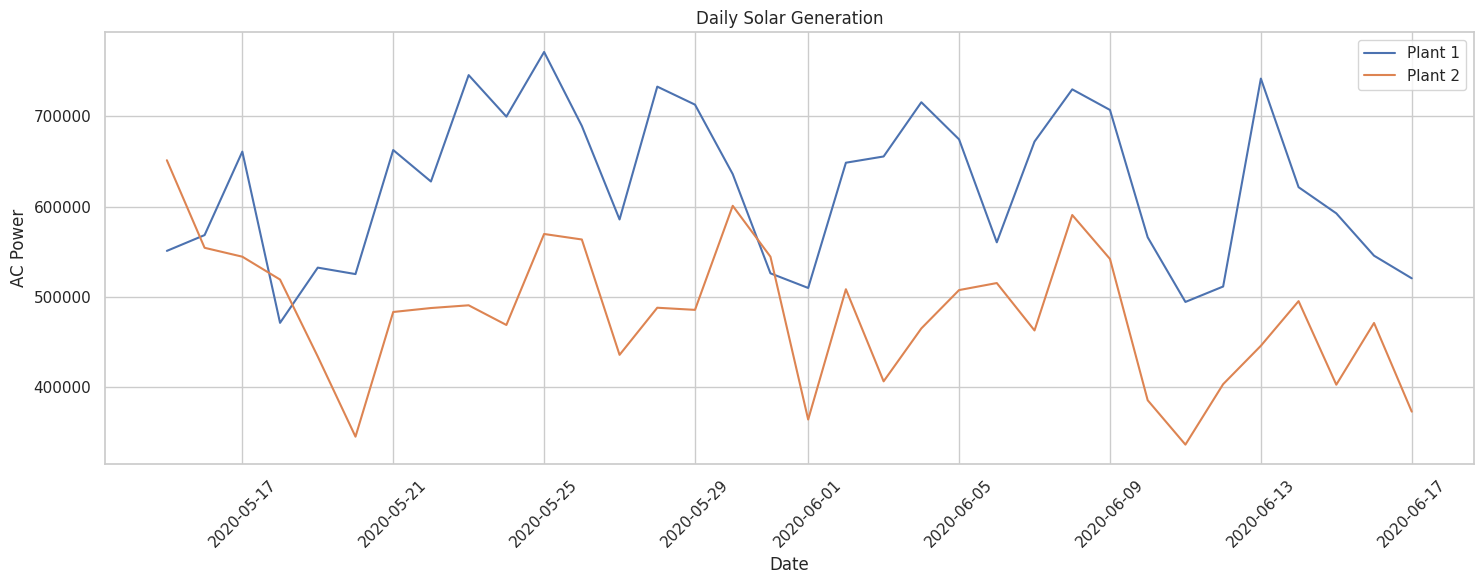

In [7]:
plant1_daily = plant1.groupby(plant1["DATE_TIME"].dt.date)["AC_POWER"].sum()
plant2_daily = plant2.groupby(plant2["DATE_TIME"].dt.date)["AC_POWER"].sum()

plt.figure(figsize=(15, 6))
plt.plot(plant1_daily.index, plant1_daily.values, label="Plant 1")
plt.plot(plant2_daily.index, plant2_daily.values, label="Plant 2")
plt.title("Daily Solar Generation")
plt.xlabel("Date")
plt.ylabel("AC Power")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

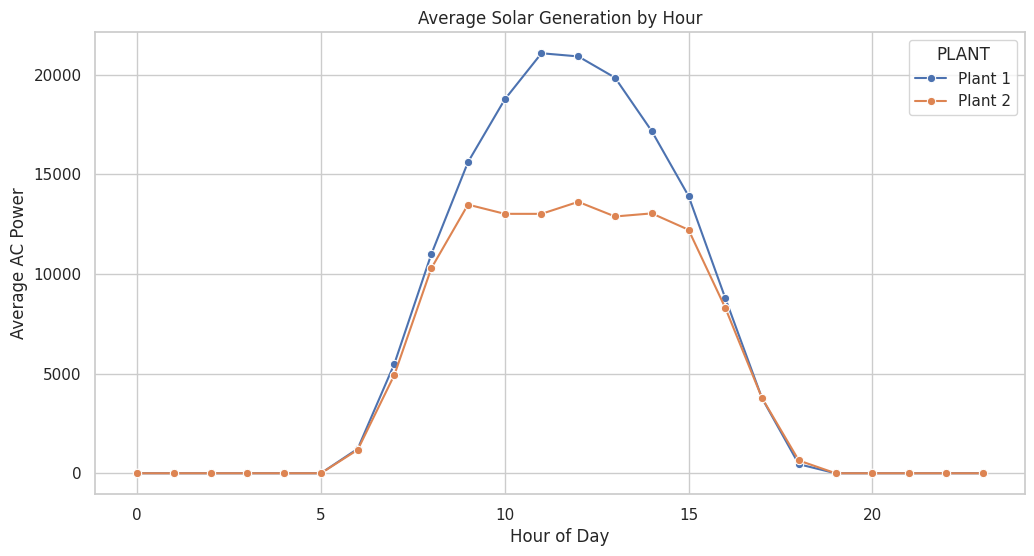

In [8]:
hourly = data.groupby(["PLANT", "HOUR"])["AC_POWER"].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly, x="HOUR", y="AC_POWER", hue="PLANT", marker="o")
plt.title("Average Solar Generation by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average AC Power")
plt.show()

PLANT
Plant 1    2.116715e+07
Plant 2    1.633403e+07
Name: AC_POWER, dtype: float64


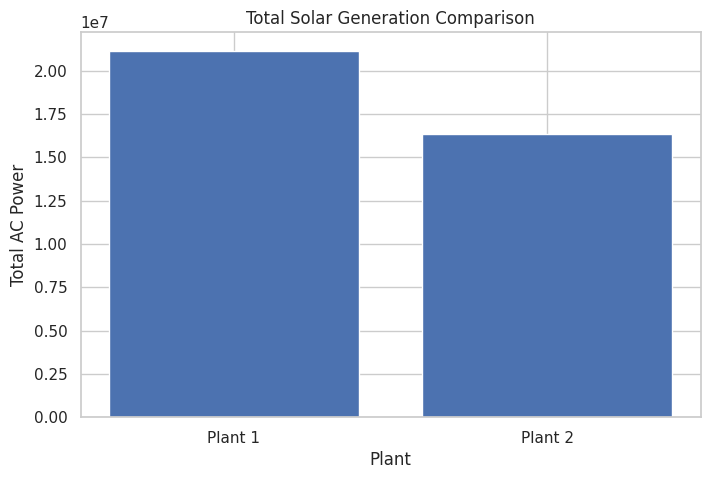

In [9]:
plant_comparison = data.groupby("PLANT")["AC_POWER"].sum()
print(plant_comparison)
plt.figure(figsize=(8, 5))
plt.bar(plant_comparison.index, plant_comparison.values)
plt.xlabel("Plant")
plt.ylabel("Total AC Power")
plt.title("Total Solar Generation Comparison")
plt.show()

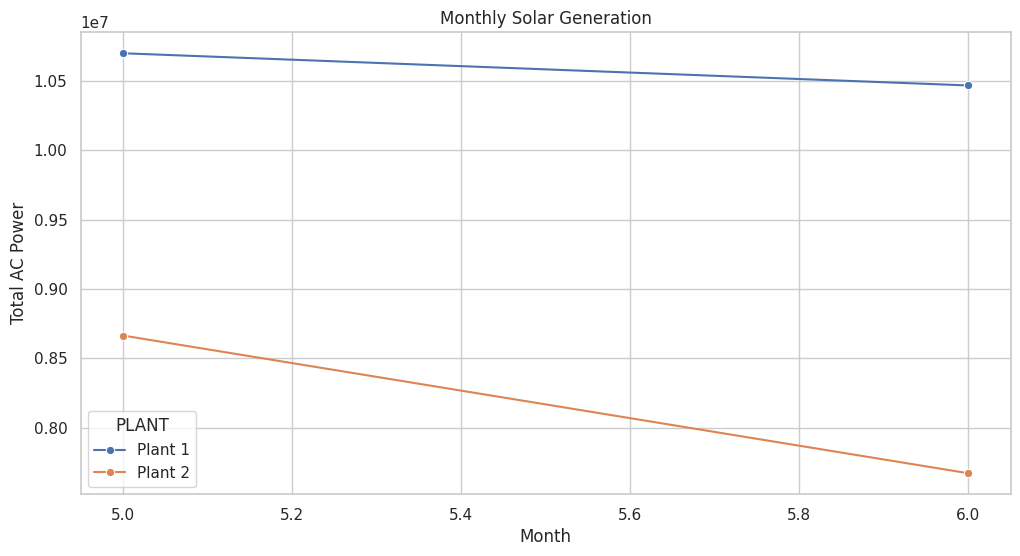

In [10]:
monthly = data.groupby(["PLANT", "MONTH"])["AC_POWER"].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x="MONTH", y="AC_POWER", hue="PLANT", marker="o")
plt.title("Monthly Solar Generation")
plt.xlabel("Month")
plt.ylabel("Total AC Power")
plt.show()

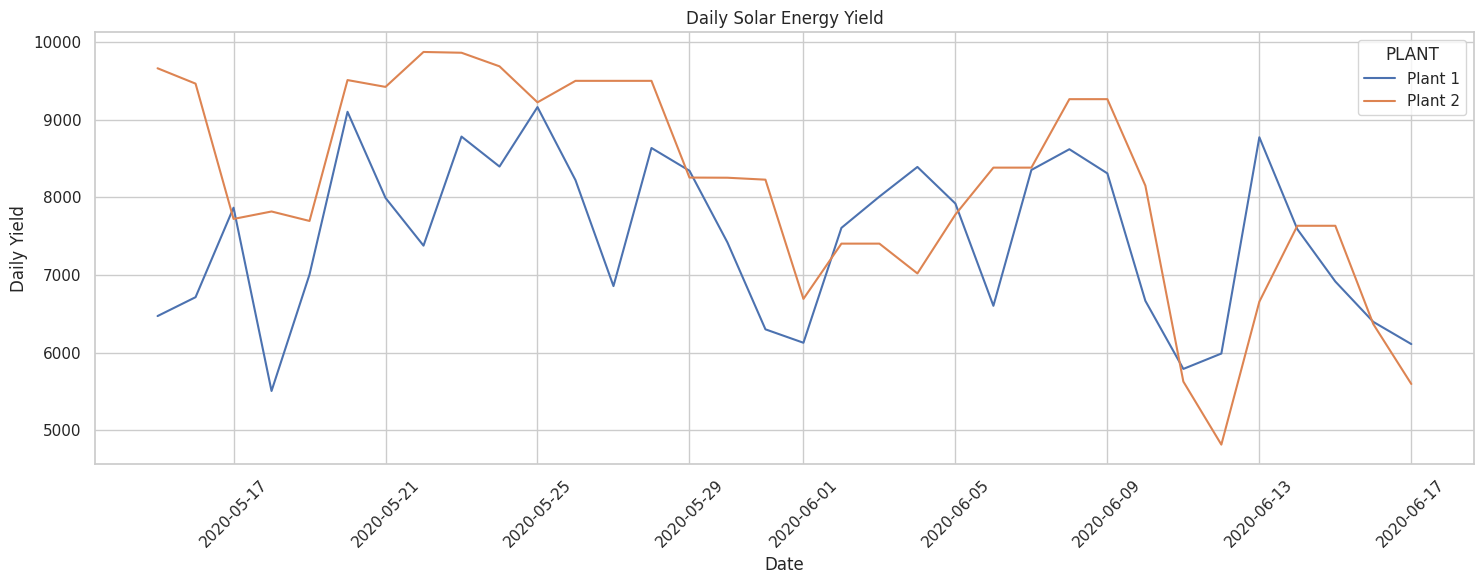

In [11]:
daily_yield = data.groupby(["PLANT", "DATE"])["DAILY_YIELD"].max().reset_index()
plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_yield, x="DATE", y="DAILY_YIELD", hue="PLANT")
plt.title("Daily Solar Energy Yield")
plt.xlabel("Date")
plt.ylabel("Daily Yield")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

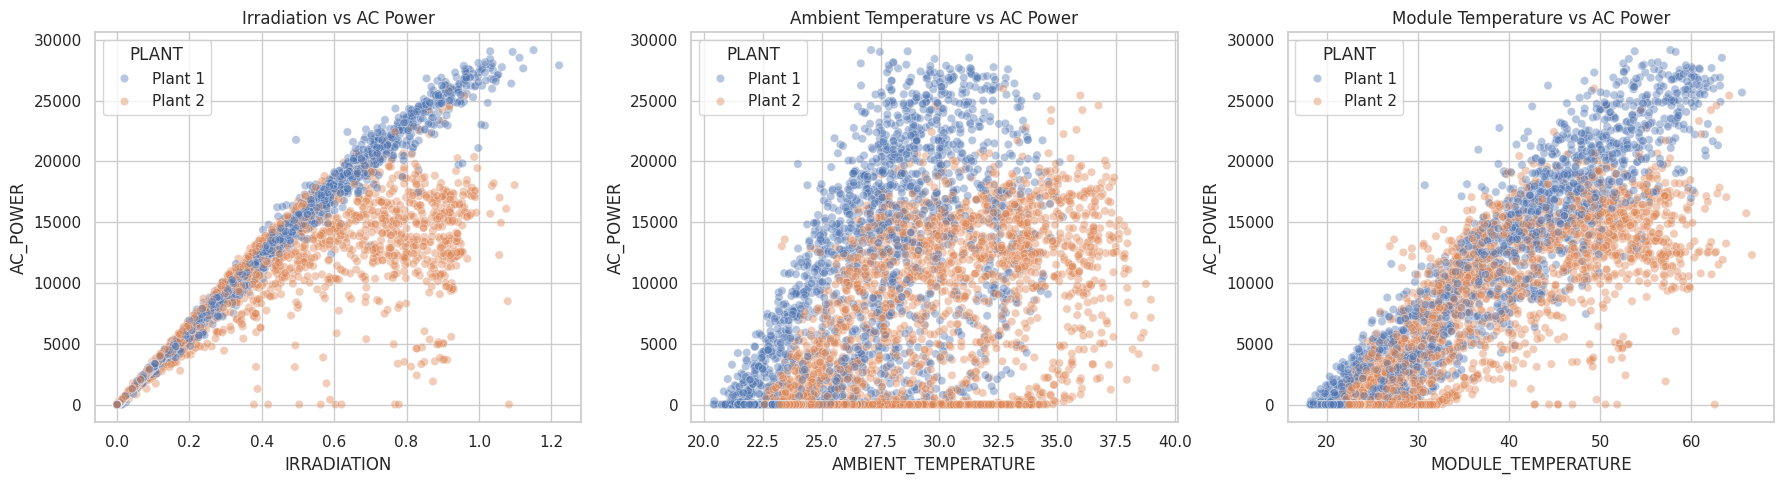

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=data, x="IRRADIATION", y="AC_POWER", hue="PLANT", alpha=0.4, ax=axes[0])
axes[0].set_title("Irradiation vs AC Power")
sns.scatterplot(data=data, x="AMBIENT_TEMPERATURE", y="AC_POWER", hue="PLANT", alpha=0.4, ax=axes[1])
axes[1].set_title("Ambient Temperature vs AC Power")
sns.scatterplot(data=data, x="MODULE_TEMPERATURE", y="AC_POWER", hue="PLANT", alpha=0.4, ax=axes[2])
axes[2].set_title("Module Temperature vs AC Power")
plt.tight_layout()
plt.show()

                     AC_POWER  DC_POWER  ...  MODULE_TEMPERATURE  IRRADIATION
AC_POWER             1.000000  0.797230  ...            0.903046     0.938184
DC_POWER             0.797230  1.000000  ...            0.629020     0.650191
AMBIENT_TEMPERATURE  0.593164  0.271066  ...            0.818020     0.654558
MODULE_TEMPERATURE   0.903046  0.629020  ...            1.000000     0.950708
IRRADIATION          0.938184  0.650191  ...            0.950708     1.000000

[5 rows x 5 columns]


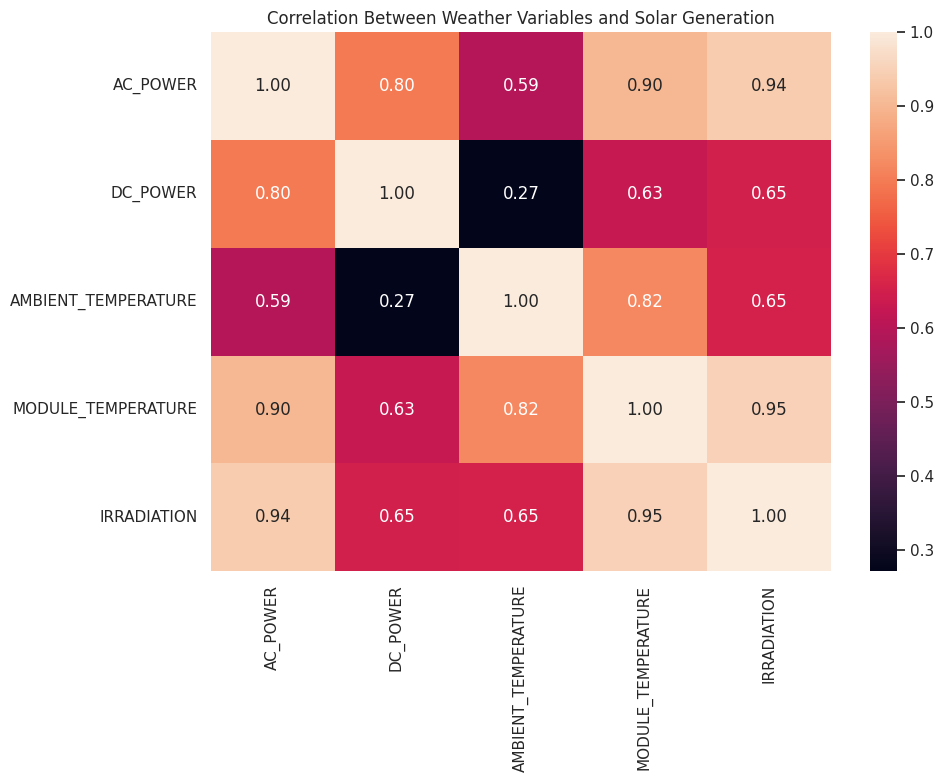

In [13]:
weather_columns = [
    "AC_POWER",
    "DC_POWER",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION"
]
correlation = data[weather_columns].corr()
print(correlation)
plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title("Correlation Between Weather Variables and Solar Generation")
plt.show()

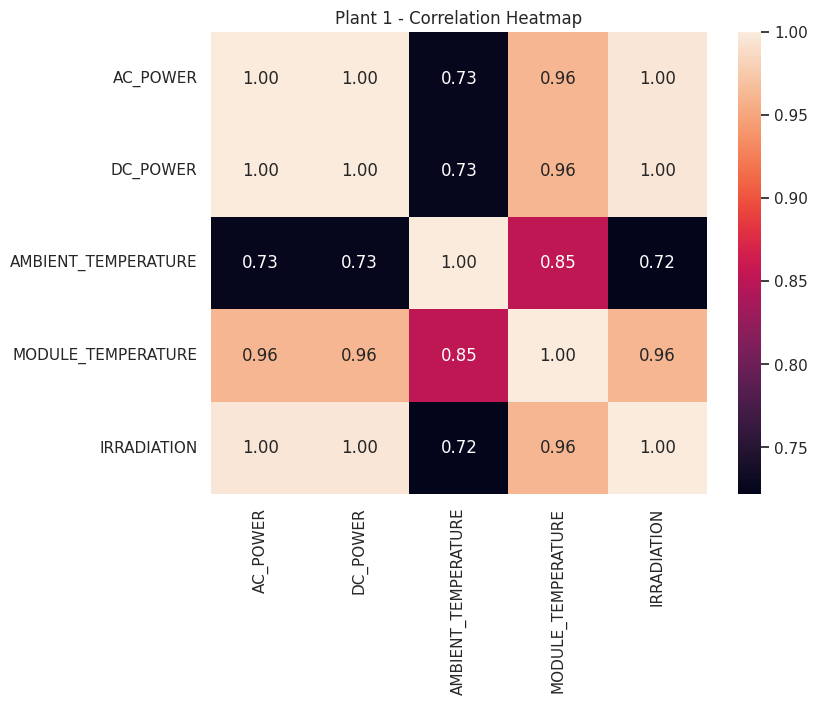

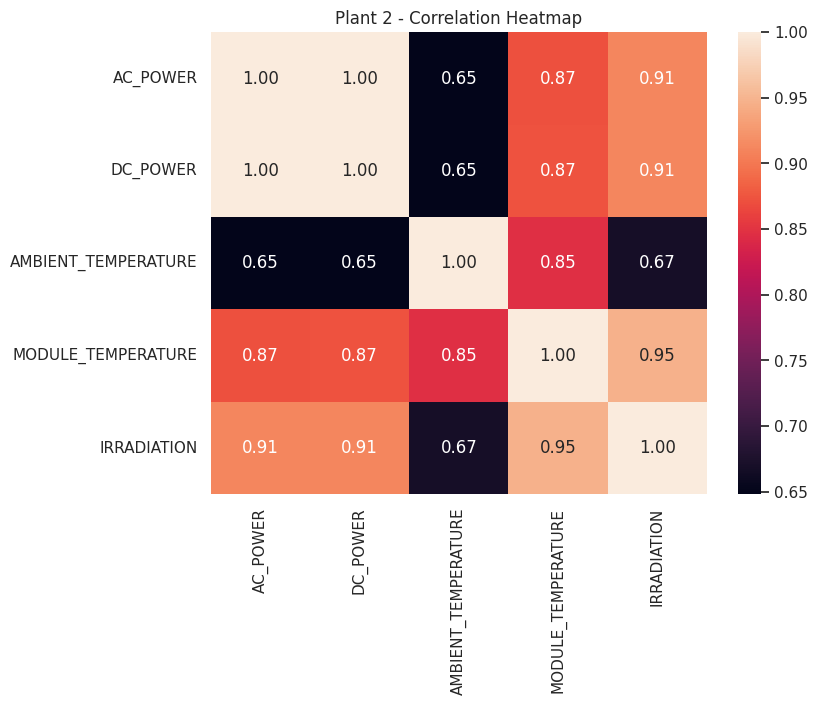

In [14]:
for plant_name in ["Plant 1", "Plant 2"]:
    plant_data = data[data["PLANT"] == plant_name]
    corr = plant_data[weather_columns].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f")
    plt.title(plant_name + " - Correlation Heatmap")
    plt.show()

## 8. Feature engineering for short-term forecasting

The report specifies 15-minute, one-hour and one-day lagged AC power. The data is sampled at 15-minute intervals, so the shifts are 1, 4 and 96 observations respectively.

In [15]:
model_data = data.sort_values(["PLANT_ID", "DATE_TIME"]).copy()

model_data["AC_POWER_LAG_15MIN"] = model_data.groupby("PLANT_ID")["AC_POWER"].shift(1)
model_data["AC_POWER_LAG_1HOUR"] = model_data.groupby("PLANT_ID")["AC_POWER"].shift(4)
model_data["AC_POWER_LAG_1DAY"] = model_data.groupby("PLANT_ID")["AC_POWER"].shift(96)

model_data = model_data.dropna().sort_values("DATE_TIME").reset_index(drop=True)

model_data["PLANT_CODE"] = model_data["PLANT_ID"].map({4135001: 0, 4136001: 1})

features = [
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRRADIATION",
    "HOUR",
    "MINUTE",
    "DAY_OF_WEEK",
    "MONTH",
    "DAY_OF_YEAR",
    "PLANT_CODE",
    "AC_POWER_LAG_15MIN",
    "AC_POWER_LAG_1HOUR",
    "AC_POWER_LAG_1DAY"
]

X = model_data[features]
y = model_data["AC_POWER"]

print("Modeling rows after lag creation:", len(model_data))
display(model_data[["DATE_TIME", "PLANT", "AC_POWER"] + features[-3:]].head())

Modeling rows after lag creation: 6224


,DATE_TIME,PLANT,AC_POWER,AC_POWER_LAG_15MIN,AC_POWER_LAG_1HOUR,AC_POWER_LAG_1DAY
0,2020-05-16 00:15:00,Plant 2,0.0,0.0,0.0,0.0
1,2020-05-16 00:30:00,Plant 2,0.0,0.0,0.0,0.0
2,2020-05-16 00:45:00,Plant 2,0.0,0.0,0.0,0.0
3,2020-05-16 01:00:00,Plant 2,0.0,0.0,0.0,0.0
4,2020-05-16 01:15:00,Plant 2,0.0,0.0,0.0,0.0


## 9. Chronological 80:20 train-test split

In [16]:
split_index = int(len(model_data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training period:", model_data["DATE_TIME"].iloc[0], "to", model_data["DATE_TIME"].iloc[split_index - 1])
print("Testing period:", model_data["DATE_TIME"].iloc[split_index], "to", model_data["DATE_TIME"].iloc[-1])

Training rows: 4979
Testing rows: 1245
Training period: 2020-05-16 00:15:00 to 2020-06-11 12:00:00
Testing period: 2020-06-11 12:00:00 to 2020-06-17 23:45:00


## 10. Random Forest forecasting model

In [17]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 496.35
RMSE: 1277.63
R²: 0.9658


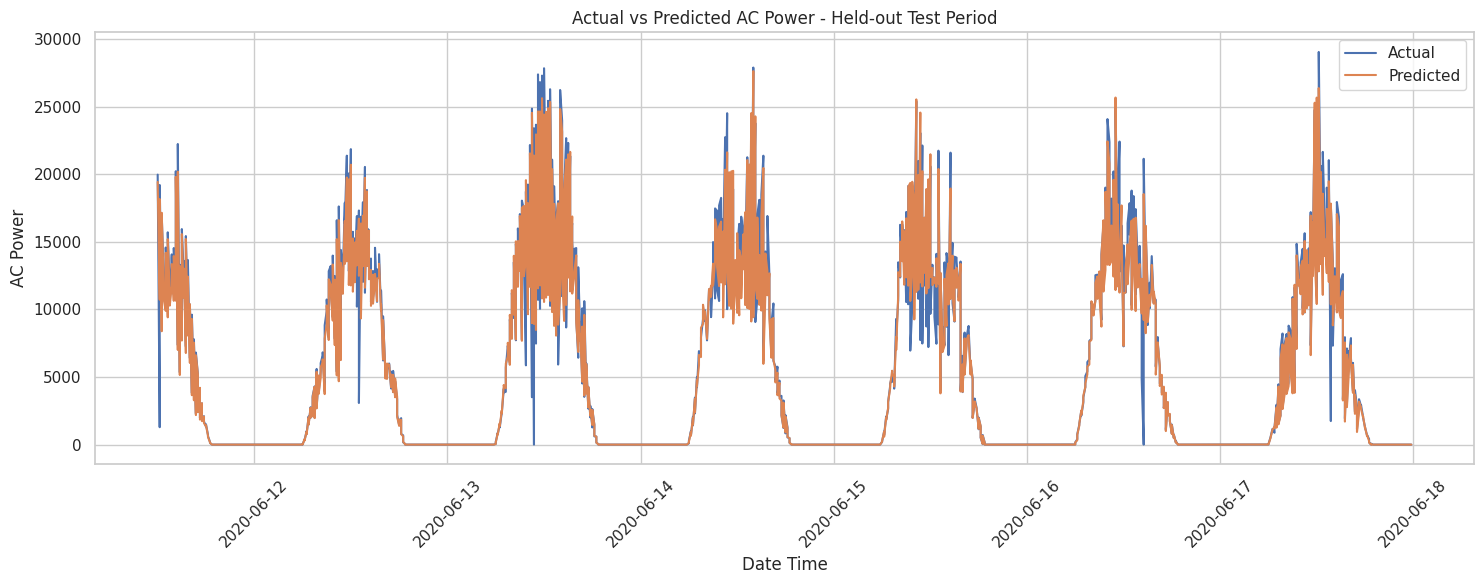

In [18]:
results = pd.DataFrame({
    "DATE_TIME": model_data["DATE_TIME"].iloc[split_index:].values,
    "ACTUAL_AC_POWER": y_test.values,
    "PREDICTED_AC_POWER": y_pred
})

plt.figure(figsize=(15, 6))
plt.plot(results["DATE_TIME"], results["ACTUAL_AC_POWER"], label="Actual")
plt.plot(results["DATE_TIME"], results["PREDICTED_AC_POWER"], label="Predicted")
plt.title("Actual vs Predicted AC Power - Held-out Test Period")
plt.xlabel("Date Time")
plt.ylabel("AC Power")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Report verification

The report states 6,416 analytical observations and the following Random Forest metrics: MAE 467.41, RMSE 1208.99 and R² 0.9693. The cell below compares those reported values with the reproducible result from this notebook.

In [19]:
reported = {
    "Analytical observations": 6416,
    "MAE": 467.41,
    "RMSE": 1208.99,
    "R2": 0.9693
}

actual = {
    "Analytical observations": len(data),
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

verification = pd.DataFrame({"Report": reported, "Notebook": actual})
verification["Difference"] = verification["Notebook"] - verification["Report"]
display(verification)

,Report,Notebook,Difference
Analytical observations,6416.0000,6416.000000,0.000000
MAE,467.4100,496.345386,28.935386
RMSE,1208.9900,1277.631871,68.641871
R2,0.9693,0.965815,-0.003485


## 12. Conclusion

The preprocessing pipeline reproduces the report’s 6,416 timestamp-level analytical observations and the reported plant-level AC totals. The Random Forest section is implemented using the documented weather, calendar, plant and lagged-generation predictors with a chronological 80:20 split. The exact reported model metrics should only be claimed if the original model configuration that generated them can be identified and reproduced.